# J=2 state cleanup with two AOM-split, EOM-modulated lasers and opposite parity

Migrated to `centrex-tlf 0.2.5` and the native Rust Lindblad solver. `retain_opposite_parity_levels=True` includes both excited-state Λ-doublet parity partners. An AOM sends 80% of the total optical power to laser 1 and 20% to laser 2; each laser has independent 17.5 MHz phase modulation with modulation depth β=1.5. The relative carrier frequency is the scan parameter `aom_shift`. Select **Python (CeNTREX_state_cleanup_new)**.


In [31]:
from importlib.metadata import version
import site
import sys

# Prefer the verified 0.2.5 wheel over the source checkout in this directory.
sys.path.insert(0, site.getsitepackages()[-1])

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sympy as smp
from scipy import constants as cst

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions, utils

print("centrex-tlf", version("centrex-tlf"))


centrex-tlf 0.2.5


In [32]:
plt.rcParams['axes.titlesize']=24
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['lines.linewidth']=3
plt.rcParams['legend.fontsize']=20

In [33]:
def doppler_shift(velocity, frequency):
    """calculate the doppler shifted frequency
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
    Returns:
        float: doppler shifted frequency in Hz
    """
    return frequency * (1 + velocity / cst.c)


def velocity_to_detuning(velocity, frequency=1.103e15, Γ=2*np.pi*1.56e6):
    """convert velocity to detuning in units of Γ
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
        Γ (float): Γ [2π⋅Hz]
    Returns:
        float: detuning in units of Γ
    """
    return (doppler_shift(velocity, frequency) - frequency) * 2 * np.pi / Γ

# save to HDF

def save_data(
    fname,
    run_name,
    scan_result,
    laser_power,
    overwrite=True,
):
    with h5py.File(fname, "a") as f:
        if run_name in f.keys():
            if overwrite:
                del f[run_name]
        try:
            dset = f.create_dataset(run_name, data = scan_result)
            dset.attrs["power"] = laser_power
        except TypeError:
            print("Error saving data!")
            return data
        
def get_data(fname, run_name):
    with h5py.File(fname, "a") as f:
        dset = f[run_name]
        scan_result = np.array(dset)
    return scan_result

In [34]:
trans = [transitions.R2_F1_7o2_F3]
polarizations = [[couplings.polarization_X, couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1 * states.CoupledBasisState(
            J=2, F=3, F1=5 / 2, mF=2, I1=1 / 2, I2=1 / 2,
            Ω=0, P=1, electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1 * states.CoupledBasisState(
            J=3, F=3, F1=7 / 2, mF=3, I1=1 / 2, I2=1 / 2,
            Ω=1, P=-1, electronic_state=states.ElectronicState.B,
        )
    ],
)


In [35]:
def gen_multipass_para(npass, loss, first_center, dz):
    power_order = []
    x_locations = []
    y_locations = []
    pass_order = utils.multipass.multipass_prism_order(npass)
    for i, pass_number in enumerate(pass_order):
        x_locations.append(first_center + i * dz)
        y_locations.append(0.0)
        power_order.append((1 - loss) ** (pass_number - 1))
    return x_locations, y_locations, power_order

xloctions, yloctions, pow = gen_multipass_para(13, 0.1, 3.5e-3, 3.5e-3)
print(pow)


[1.0, 0.31381059609000006, 0.81, 0.3874204890000001, 0.6561, 0.4782969000000001, 0.531441, 0.5904900000000001, 0.4304672100000001, 0.7290000000000001, 0.3486784401000001, 0.9, 0.2824295364810001]


In [36]:
# Experimental/runtime settings. Frequencies are angular frequencies [rad/s].
laser_frequency = 1.103e15  # Hz
vz = 184.0
vx = 0.0
y0_default = 0.0
power_default = 100e-3
laser_detuning_default = 18.5 * 2 * np.pi * 1e6
first_eom_frequency_default = 17.5 * 2 * np.pi * 1e6
second_eom_frequency_default = 17.5 * 2 * np.pi * 1e6
first_modulation_depth_default = 1.5
second_modulation_depth_default = 1.5
aom_shift_default = 18.5 * 2 * np.pi * 1e6
first_power_fraction = 0.8
second_power_fraction = 0.2
polarization_frequency_default = 0.5 * 2 * np.pi * 1e6
polarization_phase_default = 0.0

dz = 0.75e-3 * 4
dy = 6e-3 * 4
sigma_z_default = dz / 4
sigma_y_default = dy / 4
intensities_per_watt = tuple(
    np.asarray(pow, dtype=float) / (2 * np.pi * sigma_z_default * sigma_y_default)
)


In [37]:
%%time
obe_system = lindblad.generate_OBE_system_transitions(
    trans,
    transition_selectors,
    verbose=True,
    qn_compact=True,
    decay_channels=None,
    E=np.array([0.0, 0.0, 250.0]),  # V/cm
    B=np.array([0.0, 0.0, 1e-3]),  # Gauss
    retain_opposite_parity_levels=True,
)


INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
c:\Users\16612\anaconda3\envs\CeNTREX_state_cleanup_new\Lib\site-packages\centrex_tlf\states\find_states.py:635: UserWarning: Ambiguous eigenstate assignment for approximate states: 8 (assigned 8 at 0.391, runner-up 1 at 0.379), 10 (assigned 10 at 0.391, runner-up 3 at 0.379). The assigned eigenstate is not clearly preferred over the next candidate, so the labelling can change with a small change in field or with numerical noise. Treat this as a warning about the assignment as a whole, not only about the states listed: mis-assignments come in groups within a mixed manifold and a state can be assigned wrongly while its own margin looks acceptable. Track the states adiabatically instead: step the field up from ~0 in small increments and match each set of eigenvectors to the previous set.
  indices = find_exact_states_indices(
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 

CPU times: total: 14.5 s
Wall time: 9.41 s


In [38]:
%%time
params = lindblad.LindbladParameters()
t = params.time()
laser_power = params.real("laser_power", power_default)
laser_detuning = params.real("laser_detuning", laser_detuning_default)
first_eom_frequency = params.real(
    "first_eom_frequency", first_eom_frequency_default
)
second_eom_frequency = params.real(
    "second_eom_frequency", second_eom_frequency_default
)
first_modulation_depth = params.real(
    "first_modulation_depth", first_modulation_depth_default
)
second_modulation_depth = params.real(
    "second_modulation_depth", second_modulation_depth_default
)
aom_shift = params.real("aom_shift", aom_shift_default)
polarization_frequency = params.real(
    "polarization_frequency", polarization_frequency_default
)
polarization_phase = params.real("polarization_phase", polarization_phase_default)
y0 = params.real("y0", y0_default)
sigma_z = params.real("sigma_z", sigma_z_default)
sigma_y = params.real("sigma_y", sigma_y_default)
intensity_profile = params.real("intensities_per_watt", intensities_per_watt)
xlocs = params.real("xlocs", tuple(xloctions))
ylocs = params.real("ylocs", tuple(yloctions))
main_coupling = params.real(
    "main_coupling", float(abs(obe_system.couplings[0].main_coupling))
)

spatial_rabi = lindblad.multipass_2d_rabi(
    vz * t, y0, intensity_profile, xlocs, ylocs,
    sigma_z, sigma_y, main_coupling, 2.6675506e-30,
)

# AOM power split: 80% in laser 1 and 20% in laser 2. Rabi amplitude
# scales as sqrt(power). Each laser then receives its own 17.5 MHz EOM phase
# modulation with beta=1.5. The AOM shift places laser 2 relative to laser 1.
first_laser = first_power_fraction**0.5 * lindblad.phase_modulation(
    t, first_modulation_depth, first_eom_frequency
)
aom_phase = lindblad.RuntimeExpression(
    smp.exp(smp.I * aom_shift.symbol * t.expr),
    {aom_shift.name: aom_shift},
)
second_laser = (
    second_power_fraction**0.5
    * aom_phase
    * lindblad.phase_modulation(t, second_modulation_depth, second_eom_frequency)
)
two_laser_field = first_laser + second_laser
drive = laser_power**0.5 * two_laser_field * spatial_rabi

doppler_per_mps = float(utils.detuning.velocity_to_detuning(1.0, laser_frequency))
params.bind(transition_selectors[0].Ω, drive, finalize=False)
params.bind(
    transition_selectors[0].δ,
    laser_detuning + vx * doppler_per_mps,
    finalize=False,
)
px_symbol, pz_symbol = transition_selectors[0].polarization_symbols
pz_gate = lindblad.square_wave(t, polarization_frequency, polarization_phase)
params.bind(px_symbol, 1.0 - pz_gate, finalize=False)
params.bind(pz_symbol, pz_gate, finalize=False)
params._finalize()

prepared = lindblad.prepare_lindblad_problem(
    obe_system, params, backend="rust", hamiltonian_representation="decomposed"
)
print("levels (opposite parity retained):", len(obe_system.QN))
print("main coupling:", abs(obe_system.couplings[0].main_coupling))


levels (opposite parity retained): 38
main coupling: 0.09395443068104227
CPU times: total: 734 ms
Wall time: 742 ms


In [39]:
obe_system.couplings

[CouplingFields(ground_main=|X, J = 2, F1 = 5/2, F = 3, mF = 2, P = +, Ω = 0>, excited_main=|B, J = 3, F1 = 7/2, F = 3, mF = 3, P = -, Ω = 1>, main_coupling=9.40e-02+0.00e+00j]

In [40]:
print("sigma_z [m] =", sigma_z_default)
print("sigma_y [m] =", sigma_y_default)
print("laser power [mW] =", power_default * 1e3)
print("main coupling =", abs(obe_system.couplings[0].main_coupling))


sigma_z [m] = 0.00075
sigma_y [m] = 0.006
laser power [mW] = 100.0
main coupling = 0.09395443068104227


In [41]:
couplings.generate_br_dataframe(obe_system.ground, obe_system.excited,group_ground='J')

,"|B, J = 3, F1 = 7/2, F = 3>"
states,
"|X, J = 1>",0.000026
"|X, J = 2>",0.265447
"|X, J = 3>",0.484164
"|X, J = 4>",0.234637
"|X, J = 5>",0.015725


In [42]:
obe_system.H_symbolic

Matrix([
[-417725790057.005,                                                0,                                                0,                                                 0,                                               0,                                                0,                                               0,                                                0,                                               0,                                               0,                                                0,                                               0,                                                0,                                              0,                                               0,                                               0,                                               0,                                               0,                                                0,                                               0,                                 

In [43]:
qn_select = states.QuantumSelector(J=2, electronic=states.ElectronicState.X)
ground_idx = np.asarray(qn_select.get_indices(obe_system.QN), dtype=int).ravel()
rho0 = np.zeros(obe_system.H_symbolic.shape, dtype=np.complex128)
rho0[ground_idx, ground_idx] = 1.0 / ground_idx.size
print("initial states:", ground_idx.size, "trace:", np.trace(rho0).real)


initial states: 20 trace: 1.0


In [44]:
print("laser 1 power fraction =", first_power_fraction)
print("laser 2 power fraction =", second_power_fraction)
print("laser 1 field amplitude =", np.sqrt(first_power_fraction))
print("laser 2 field amplitude =", np.sqrt(second_power_fraction))
print("EOM frequencies [MHz] =", first_eom_frequency_default / (2*np.pi*1e6), second_eom_frequency_default / (2*np.pi*1e6))
print("EOM modulation depths =", first_modulation_depth_default, second_modulation_depth_default)


laser 1 power fraction = 0.8
laser 2 power fraction = 0.2
laser 1 field amplitude = 0.8944271909999159
laser 2 field amplitude = 0.4472135954999579
EOM frequencies [MHz] = 17.5 17.5
EOM modulation depths = 1.5 1.5


In [45]:
t_end = 0.05 / vz
saveat = np.append(np.arange(0.0, t_end, 1e-6), t_end)
solver_options = dict(
    solver="dopri5",
    execution_mode="expanded_sparse",
    dt=2e-9,
    reltol=1e-7,
    abstol=1e-9,
    maxiters=500_000,
)


In [46]:
results = lindblad.solve_lindblad(
    prepared,
    rho0,
    (0.0, t_end),
    saveat=saveat,
    output="populations",
    output_when="saveat",
    **solver_options,
)
populations = results.values


In [47]:
qn_select_excited = states.QuantumSelector(electronic=states.ElectronicState.B)
excited_idx = np.asarray(qn_select_excited.get_indices(obe_system.QN), dtype=int).ravel()

nT, nS = populations.shape
print("number of time bins =", nT)
print("number of states =", nS)
print("final total population =", populations[-1].sum())


number of time bins = 273
number of states = 38
final total population = 0.9999999999999898


In [48]:
# J1_idx = states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J0_idx = states.QuantumSelector(J=0,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J1_idx = states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

J2_others_idx = []
for stuff in states.QuantumSelector(J=2,electronic=states.ElectronicState.X).get_indices(obe_system.QN):
    if stuff not in ground_idx:
        J2_others_idx.append(stuff)
        
J3_idx = states.QuantumSelector(J=3,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J4_idx = states.QuantumSelector(J=4,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J5_idx = states.QuantumSelector(J=5,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

state clean up efficiency = 0.990496990443165
photons per molecule = 1.528027981490826


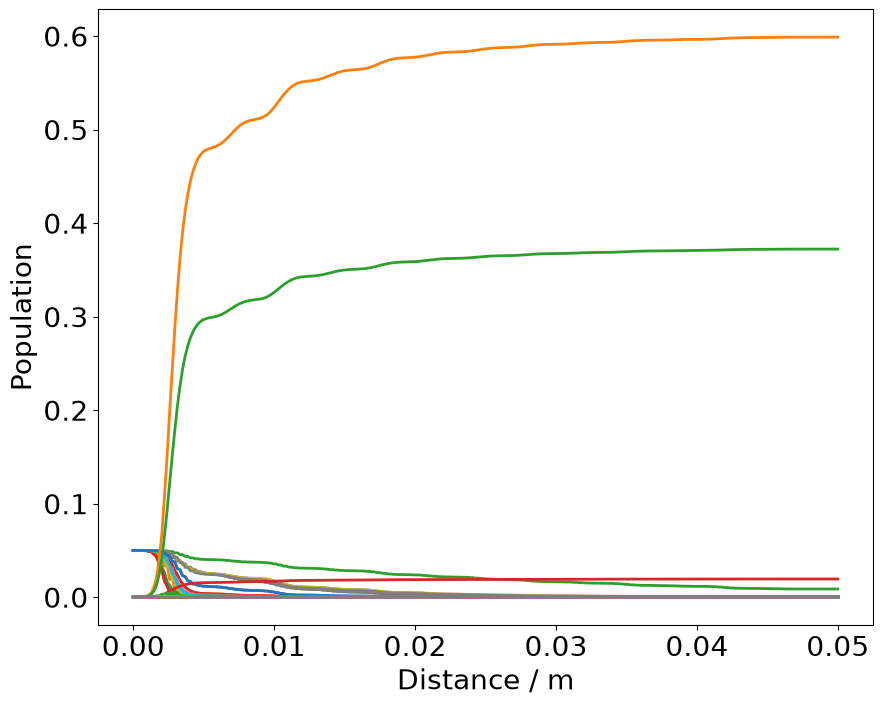

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(results.t * vz, populations, lw=2)
ax.set_xlabel("Distance / m")
ax.set_ylabel("Population")

clean_up_eff = np.sum(populations[-1, ground_idx])
nphotons = np.trapezoid(populations[:, excited_idx].sum(axis=1), x=results.t) * hamiltonian.Γ
print("state clean up efficiency =", 1 - clean_up_eff)
print("photons per molecule =", nphotons)


In [50]:
ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[:, idx])


remainder in ground state = 0.009503009556835008
remainder in J=0 = []
remainder in J=2, other state = 0.0
remainder in J=1 = [4.58047893e-05]
remainder in J=3 = [0.59881849]
remainder in J=4 = [0.37219572]
remainder in J=5 = [0.01943697]


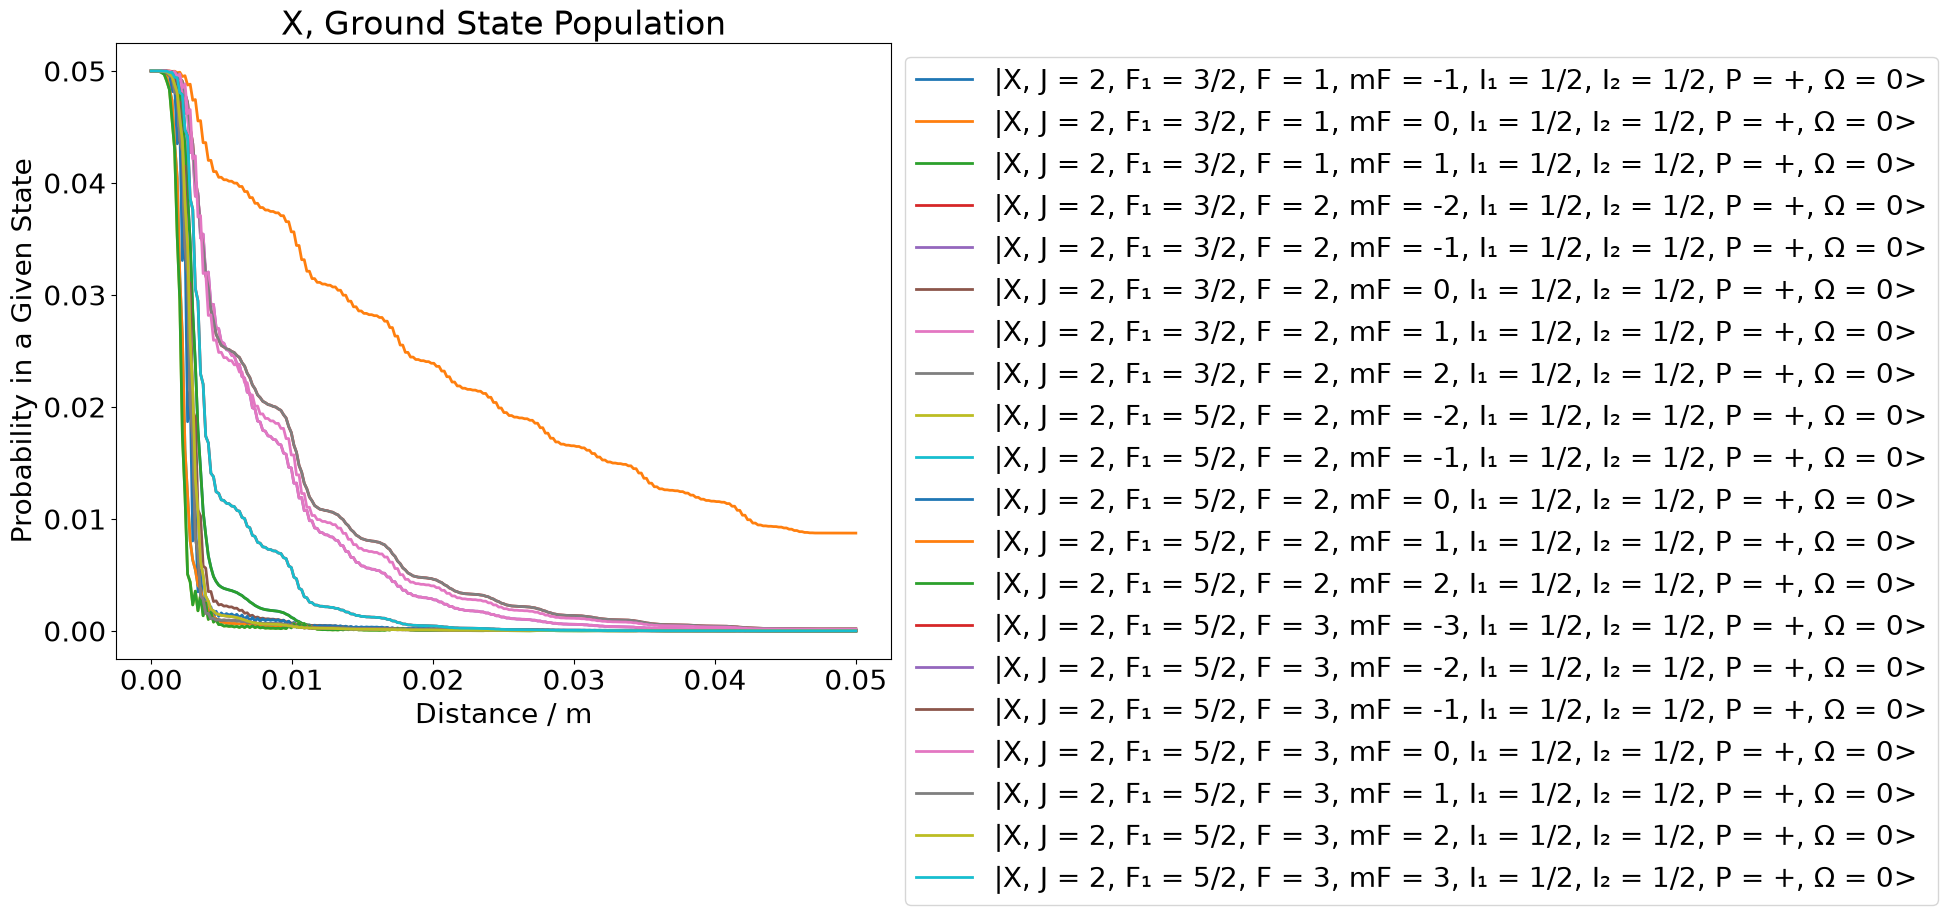

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
stop_dist = 0.05
stop = np.argmin(abs(results.t - stop_dist / vz))

ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[-1, idx])
ax.set_title("X, Ground State Population")
ax.set_ylabel("Probability in a Given State")
ax.set_xlabel("Distance / m")
ax.legend(bbox_to_anchor=[1, 1])

print("remainder in ground state =", np.sum(ground_final))
print("remainder in J=0 =", populations[stop, J0_idx])
print("remainder in J=2, other state =", np.sum(populations[stop, J2_others_idx]))
print("remainder in J=1 =", populations[stop, J1_idx])
print("remainder in J=3 =", populations[stop, J3_idx])
print("remainder in J=4 =", populations[stop, J4_idx])
print("remainder in J=5 =", populations[stop, J5_idx])


#### AOM frequency-shift scan


In [ ]:
aom_shifts = np.linspace(10, 40, 41) * 2 * np.pi * 1e6


In [ ]:
# Native Rust scan settings. The scan changes the AOM frequency shift while
# preserving the 80%/20% optical-power split and both EOM settings.
scan_solver_options = dict(
    solver="dopri5", execution_mode="expanded_sparse",
    output="populations", output_when="final",
    dt=2e-9, reltol=1e-7, abstol=1e-9, maxiters=500_000, parallel=True,
)


In [ ]:
# Native Rust scan; no Julia OBEEnsembleProblem is required.


In [ ]:
frequency_scan = lindblad.grid_scan(
    prepared,
    rho0,
    (0.0, t_end),
    scan={"aom_shift": aom_shifts},
    **scan_solver_options,
)
frequency_populations = frequency_scan.values.reshape(
    len(aom_shifts), len(obe_system.QN)
)
scan_result_ground = frequency_populations[:, ground_idx].sum(axis=-1)


In [ ]:
import matplotlib
fig,ax = plt.subplots(figsize = [7,4])
cax = ax.plot(aom_shifts / (2*np.pi*1e6), scan_result_ground)
ax.set_ylabel('remaining population')
ax.set_xlabel('AOM shift / MHz')
ax.set_title("laser power:" + str(int(power*1e3)) + "mW")

#### Fine AOM frequency-shift scan


In [ ]:
aom_shifts = np.linspace(30, 34, 41) * 2 * np.pi * 1e6


In [ ]:
# Reuse the prepared problem for the finer AOM-shift scan.


In [ ]:
frequency_scan = lindblad.grid_scan(
    prepared,
    rho0,
    (0.0, t_end),
    scan={"aom_shift": aom_shifts},
    **scan_solver_options,
)
frequency_populations = frequency_scan.values.reshape(
    len(aom_shifts), len(obe_system.QN)
)
scan_result_ground = frequency_populations[:, ground_idx].sum(axis=-1)


In [ ]:
import matplotlib
fig,ax = plt.subplots(figsize = [7,4])
cax = ax.plot(aom_shifts / (2*np.pi*1e6), scan_result_ground)
ax.set_ylabel('remaining population')
ax.set_xlabel('AOM shift / MHz')
ax.set_title("laser power:" + str(int(power*1e3)) + "mW")

#### Y location & Y diamater scan

In [ ]:
yloc = np.linspace(-12, 12, 50) * 1e-3
ydia = np.linspace(10, 50, 5) * 1e-3


In [ ]:
y_scan = lindblad.grid_scan(
    prepared,
    rho0,
    (0.0, t_end),
    scan={"y0": yloc, "sigma_y": ydia / 4},
    **scan_solver_options,
)
y_populations = y_scan.values.reshape(len(yloc), len(ydia), len(obe_system.QN))
scan_result_ground = y_populations[..., ground_idx].sum(axis=-1).T
print("result shape [beam diameter, y location] =", scan_result_ground.shape)


In [ ]:
import matplotlib
fig,ax = plt.subplots(figsize = [7,4])
# cax = ax.pcolormesh(yloc * 1e3, ydia * 1e3, scan_result_ground, norm=matplotlib.colors.LogNorm())
cax = ax.pcolormesh(yloc * 1e3, ydia * 1e3, scan_result_ground, norm=matplotlib.colors.LogNorm(vmax = 0.05))
cbar = fig.colorbar(cax)
ax.set_xlabel('y location / mm')
ax.set_ylabel('y diamater/ mm')
ax.set_title("laser power:" + str(80) + "mW")